In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


base_path = "/content/drive/MyDrive/TFG"

train_csv = base_path + "/df_train_clean.csv"
valid_csv = base_path + "/df_valid_clean.csv"

train_images_path = "/content/train_clean_images"
valid_images_path = "/content/valid_clean_images"

output_dir = base_path + "/modelo_final_holdout"
os.makedirs(output_dir, exist_ok=True)

learning_rate = 0.001
num_epochs = 10
batch_size = 32
threshold = 0.4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


In [ ]:


df_train = pd.read_csv(train_csv)
df_valid = pd.read_csv(valid_csv)

urgent_cols = [
    "Pneumothorax",
    "Edema",
    "Pleural Effusion",
    "Enlarged Cardiomediastinum"
]

df_train["urgent"] = (df_train[urgent_cols] == 1).any(axis=1).astype(int)
df_valid["urgent"] = (df_valid[urgent_cols] == 1).any(axis=1).astype(int)

print("Train:", len(df_train))
print(df_train["urgent"].value_counts())

print("Valid:", len(df_valid))
print(df_valid["urgent"].value_counts())

Train: 12399
urgent
0    7455
1    4944
Name: count, dtype: int64
Valid: 3091
urgent
0    1883
1    1208
Name: count, dtype: int64


In [ ]:


if not os.path.exists(train_images_path):
    !unzip -oq "/content/drive/MyDrive/TFG/train_clean_images.zip" -d "/content/"
    print("Train descomprimido")
else:
    print("Train ya estaba descomprimido")

if not os.path.exists(valid_images_path):
    !unzip -oq "/content/drive/MyDrive/TFG/valid_clean_images.zip" -d "/content/"
    print("Valid descomprimido")
else:
    print("Valid ya estaba descomprimido")

print("Existe train:", os.path.exists(train_images_path))
print("Existe valid:", os.path.exists(valid_images_path))

Train descomprimido
Valid descomprimido
Existe train: True
Existe valid: True


In [ ]:


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class CheXpertDataset(Dataset):
    def __init__(self, dataframe, base_path, transform=None):
        self.df = dataframe
        self.base_path = base_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        relative_path = row["Path"].replace("CheXpert-v1.0/train/", "")
        img_path = os.path.join(self.base_path, relative_path)

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["urgent"], dtype=torch.float32)

        return img, label

train_dataset = CheXpertDataset(df_train, train_images_path, transform)
valid_dataset = CheXpertDataset(df_valid, valid_images_path, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:


model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(in_features=2048, out_features=1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Modelo preparado")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Modelo preparado


In [ ]:


train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

losses_df = pd.DataFrame({
    "epoch": list(range(1, num_epochs + 1)),
    "loss": train_losses
})

losses_df.to_csv(f"{output_dir}/final_train_losses.csv", index=False)

torch.save(model.state_dict(), f"{output_dir}/modelo_final_resnet50_lr001_th04.pth")

print("Entrenamiento final guardado")

Epoch [1/10] - Loss: 0.4950
Epoch [2/10] - Loss: 0.4464
Epoch [3/10] - Loss: 0.4218
Epoch [4/10] - Loss: 0.4094
Epoch [5/10] - Loss: 0.3904
Epoch [6/10] - Loss: 0.3760
Epoch [7/10] - Loss: 0.3469
Epoch [8/10] - Loss: 0.3109
Epoch [9/10] - Loss: 0.2593
Epoch [10/10] - Loss: 0.2032
Entrenamiento final guardado


In [ ]:


model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels).ravel()
all_probs = np.array(all_probs).ravel()

all_preds = (all_probs >= threshold).astype(int)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
auc_score = roc_auc_score(all_labels, all_probs)
brier = brier_score_loss(all_labels, all_probs)
logloss = log_loss(all_labels, all_probs)

metricas_finales = pd.DataFrame({
    "Métrica": [
        "Accuracy", "Precision", "Recall", "F1-score",
        "AUC", "Brier Score", "LogLoss"
    ],
    "Valor": [
        accuracy, precision, recall, f1,
        auc_score, brier, logloss
    ]
})

metricas_finales["Valor"] = metricas_finales["Valor"].round(4)

metricas_finales.to_csv(f"{output_dir}/metricas_finales_valid.csv", index=False)

np.save(f"{output_dir}/final_labels.npy", all_labels)
np.save(f"{output_dir}/final_probs.npy", all_probs)
np.save(f"{output_dir}/final_preds.npy", all_preds)

metricas_finales

,Métrica,Valor
0,Accuracy,0.6616
1,Precision,0.5418
2,Recall,0.8684
3,F1-score,0.6673
4,AUC,0.8271
5,Brier Score,0.2527
6,LogLoss,1.0508


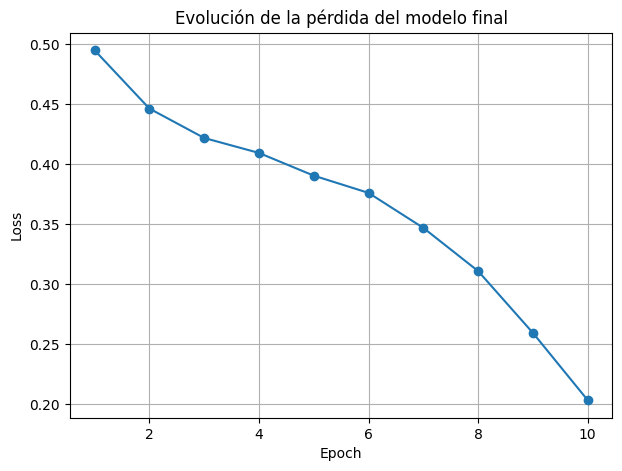

In [ ]:


plt.figure(figsize=(7, 5))
plt.plot(losses_df["epoch"], losses_df["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida del modelo final")
plt.grid(True)

plt.savefig(f"{output_dir}/figura_loss_modelo_final.png", dpi=300, bbox_inches="tight")
plt.show()

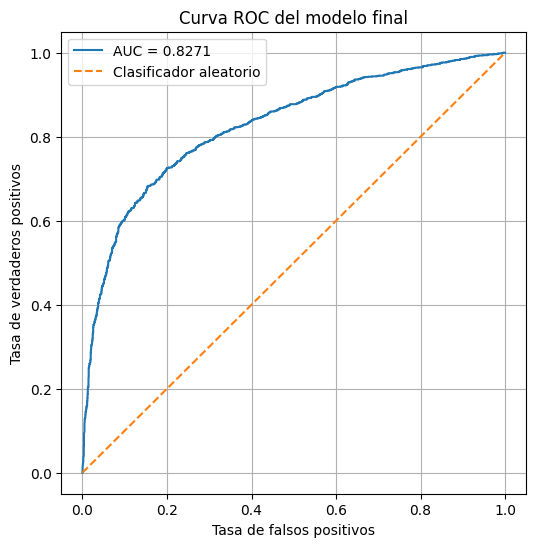

In [ ]:


fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC del modelo final")
plt.legend()
plt.grid(True)

plt.savefig(f"{output_dir}/figura_roc_modelo_final.png", dpi=300, bbox_inches="tight")
plt.show()

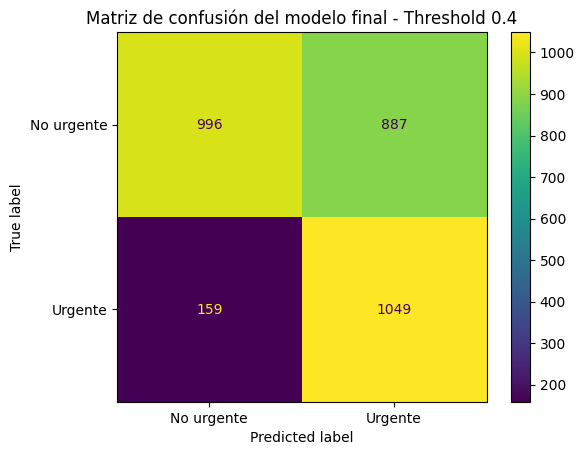

array([[ 996,  887],
       [ 159, 1049]])

In [ ]:


cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No urgente", "Urgente"]
)

disp.plot(values_format="d")
plt.title(f"Matriz de confusión del modelo final - Threshold {threshold}")

plt.savefig(f"{output_dir}/figura_matriz_confusion_modelo_final.png", dpi=300, bbox_inches="tight")
plt.show()

cm